# Численное дифференциирование

## Задание 1

Используем формулы для производных по 4 точкам и строим графики.

Для проверки соответсвия наклона используем апроксимацию в матричном виде

In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Численные формулы дифференцирования
def D3(f, x0, h):
    return (-1 * f(x0) + 3*f(x0+h) - 3*f(x0+2*h) + f(x0+3*h)) / h**3  # O(h)

def D2(f, x0, h):
    return (2*f(x0) - 5*f(x0+h) + 4*f(x0+2*h) - f(x0+3*h)) / h**2  # O(h^2)

def D1(f, x0, h):
    return (-11/6*f(x0) + 3*f(x0+h) - 3/2*f(x0+2*h) + 1/3*f(x0+3*h)) / h  # O(h^3)


def create_graphs(f_expr, poly_degree, write_df=True):
    x = sp.Symbol('x')
    
    # Вычисляем производные
    der_f1 = sp.diff(f_expr, x, 1)
    der_f2 = sp.diff(f_expr, x, 2)
    der_f3 = sp.diff(f_expr, x, 3)
    
    # Преобразуем в числовые функции
    der_f1_exact = sp.lambdify(x, der_f1, 'numpy')
    der_f2_exact = sp.lambdify(x, der_f2, 'numpy')
    der_f3_exact = sp.lambdify(x, der_f3, 'numpy')
    f_num = sp.lambdify(x, f_expr, 'numpy')

    def calculate_error(f_approx, f_exact, der_num=""):
        """Вычисляет ошибки и создаёт таблицу"""
        errs = []
        data = []
        
        print(f'f(x) = {str(f_expr):<50}')
        print(f'{der_num} derivative: {str([der_f1, der_f2, der_f3][int(der_num[0])-1]):<48}')
        
        for h in hs:
            approx = f_approx(f_num, x0, h)
            exact = f_exact(x0)
            abs_error = abs(approx - exact)
            errs.append(abs_error)
            data.append({
                'h': f'{h:.0e}',
                'Приблиз.': f'{approx:.6e}',
                'Точное': f'{exact:.6e}',
                'Ошибка': f'{abs_error:.6e}'
            })

        if write_df:
            df = pd.DataFrame(data)
            print(df.to_string(index=False))
        return np.array(errs)

    def calculate_approx(h_vals, errors):
        """
        Аппроксимация ошибки полиномом в логарифмическом пространстве
        log(error) ≈ a0 + a1*log(h) + a2*log(h)^2 + a3*log(h)^3
        """
        # Фильтруем только валидные значения (ошибка > 0)
        valid_mask = errors > 1e-20
        h_valid = h_vals[valid_mask]
        err_valid = errors[valid_mask]
        
        if len(h_valid) < 4:
            print('Недостаточно данных для аппроксимации')
            return np.full_like(errors, np.nan)
        
        # Работаем в логарифмическом пространстве
        log_h = np.log10(h_valid)
        log_err = np.log10(err_valid)
        
        # Строим матрицу для МНК: log(error) ≈ a0 + a1*log(h) + a2*log(h)^2 + a3*log(h)^3
        X = np.column_stack([np.ones_like(log_h), log_h, log_h**2, log_h**3])
        
        # Решаем систему для коэффициентов
        alpha = np.linalg.solve(X.T @ X, X.T @ log_err)
        a0, a1, a2, a3 = alpha
        
        # Вычисляем аппроксимацию для всех точек
        log_h_all = np.log10(h_vals)
        log_approx = a0 + a1*log_h_all + a2*log_h_all**2 + a3*log_h_all**3
        approx_errors = 10**log_approx
        
        print(f'Коэффициенты (лог-пространство): a0={a0:.3f}, a1={a1:.3f}, a2={a2:.3f}, a3={a3:.3f}', end='\n\n')
        
        return approx_errors
    
    
    x0 = 1.0
    hs = np.logspace(start=-1, stop=-13, num=13, base=10)


    fig = plt.figure(figsize=(16, 5))
    
    # Цвета для каждого графика
    colors = ['#1f77b4', '#d62728', '#2ca02c']
    
    # 1-я производная
    ax1 = plt.subplot(1, 3, 1)
    errs1 = calculate_error(D1, der_f1_exact, "1st")
    ax1.loglog(hs, errs1, 'o-', linewidth=2.5, markersize=8, color=colors[0], label='Численная ошибка', zorder=3)
    
    approx_errs1 = calculate_approx(hs, errs1)
    ax1.loglog(hs, approx_errs1, 's--', linewidth=2.5, markersize=7, color='orange', alpha=0.7, label='Аппроксимация')
    
    ax1.set_xlabel('Шаг h', fontsize=12, fontweight='bold', color='#333333')
    ax1.set_ylabel('Абсолютная ошибка', fontsize=12, fontweight='bold', color='#333333')
    ax1.set_title('1-я производная (<= Сh³)', fontsize=13, fontweight='bold', color='#333333', pad=15)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7, color='#888888')
    ax1.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#cccccc')
    
    # 2-я производная
    ax2 = plt.subplot(1, 3, 2)
    errs2 = calculate_error(D2, der_f2_exact, "2nd")
    ax2.loglog(hs, errs2, 's-', linewidth=2.5, markersize=8, color=colors[1], label='Численная ошибка', zorder=3)

    approx_errs2 = calculate_approx(hs, errs2)
    ax2.loglog(hs, approx_errs2, '^--', linewidth=2.5, markersize=7, color='orange', alpha=0.7, label='Аппроксимация')
    
    ax2.set_xlabel('Шаг h', fontsize=12, fontweight='bold', color='#333333')
    ax2.set_ylabel('Абсолютная ошибка', fontsize=12, fontweight='bold', color='#333333')
    ax2.set_title('2-я производная (<= Ch²)', fontsize=13, fontweight='bold', color='#333333', pad=15)
    ax2.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7, color='#888888')
    ax2.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#cccccc')
    
    # 3-я производная
    ax3 = plt.subplot(1, 3, 3)
    errs3 = calculate_error(D3, der_f3_exact, "3rd")
    ax3.loglog(hs, errs3, '^-', linewidth=2.5, markersize=8, color=colors[2], label='Численная ошибка', zorder=3)

    approx_errs3 = calculate_approx(hs, errs3)
    ax3.loglog(hs, approx_errs3, 'o--', linewidth=2.5, markersize=7, color='orange', alpha=0.7, label='Аппроксимация')
    
    ax3.set_xlabel('Шаг h', fontsize=12, fontweight='bold', color='#333333')
    ax3.set_ylabel('Абсолютная ошибка', fontsize=12, fontweight='bold', color='#333333')
    ax3.set_title('3-я производная (<= Ch)', fontsize=13, fontweight='bold', color='#333333', pad=15)
    ax3.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7, color='#888888')
    ax3.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#cccccc')
    
    # Общий заголовок
    fig.suptitle(f'Анализ численного дифференцирования: f(x) = x^{poly_degree}', 
                 fontsize=15, fontweight='bold', color='#333333', y=0.98)
    
    plt.show()


# Основной код
x = sp.Symbol('x')

# Тестируем на разных степенях полинома
for degree in range(1, 5):
    f = x**degree
    print(f'\n{"━"*70}')
    print(f'  ПОЛИНОМ СТЕПЕНИ {degree}: f(x) = x^{degree}')
    print(f'{"━"*70}\n')
    create_graphs(f, degree, write_df=False)
    print()


Выведем **Вторую производную** по *пяти точкам* с использованием многочлена Ньютона:

Пусть заданы пять точек $(x_i, y_i)$, $y_i = f(x_i)$, $i = 0,\dots,4$.

Интерполяционный многочлен Ньютона степени 4:
$$
L_4(x) = f[x_0] 
+ f[x_0,x_1](x-x_0) 
+ f[x_0,x_1,x_2](x-x_0)(x-x_1)
+ f[x_0,x_1,x_2,x_3](x-x_0)(x-x_1)(x-x_2)
+ f[x_0,x_1,x_2,x_3,x_4](x-x_0)(x-x_1)(x-x_2)(x-x_3).
$$

Разделённые разности:
$$
f[x_i] = y_i,
$$
$$
f[x_i,x_{i+1}] = \frac{f[x_{i+1}] - f[x_i]}{x_{i+1}-x_i},
$$
$$
f[x_i,\dots,x_{i+k}] = 
\frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}.
$$

Ошибка (остаточный член):
$$
R_4(x) = f(x) - L_4(x) 
= f[x, x_0,x_1,x_2,x_3,x_4] (x-x_0)(x-x_1)(x-x_2)(x-x_3)(x-x_4),
$$

### Первая производная:

\begin{align}
L'(x) = f[x_0, x_1] + f[x_0, x_1, x_2]((x - x_1) + (x - x_2)) + f[x_0, x_1, x_2, x_3]((x - x_1)(x - x_2) + (x - x_0)(2x - x_1 - x_2)) + \\ f[x_0, x_1, x_2, x_3, x_4]((x-x_1)(x-x_2)(x-x_3) + (x-x_0)(x-x_2)(x-x_3) + (x - x_0)(x - x_1)(2x - x_1 - x_2))
\end{align}

\begin{align}
R'(x) = f[x, x, x_0, x_1, x_2, x_3, x_4](x - x_0))(x - x_1)(x - x_2)(x - x_3)(x - x_4) + f[x, x_0, x_1, x_2, x_3, x_4]((x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\(x-x_0)(x-x_2)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_2)(2x - x_3 - x_4))
\end{align}

### Вторая производная

\begin{align}
L''(x) = 2f[x_0, x_1, x_2] + 2f[x_0, x_1, x_2, x_3](3x - x_0 - x_1 - x_2)) + 2f[x_0, x_1, x_2, x_3, x_4]((x-x_2)(x-x_3) + (x - x_1)(2x - x_2 - x_3) + 2(x-x_0)(3x - x_1 - x_2 - x_3))
\end{align}

\begin{align}
R''(x) &= f[x, x, x, x_0, x_1, x_2, x_3, x_4](x - x_0))(x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\f[x, x, x_0, x_1, x_2, x_3, x_4]((x - x_1))(x - x_2)(x - x_3)(x - x_4) + (x-x_0)(x-x_1)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_2)(2x - x_3 - x_4)) + \\f[x, x, x_0, x_1, x_2, x_3, x_4](x - x_0))(x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\f[x, x_0, x_1, x_2, x_3, x_4]((x - x_1)(x - x_2)(x - x_3)(x - x_4) + \\(x-x_0)(x-x_2)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_3)(x-x_4) + (x-x_0)(x-x_1)(x-x_2)(2x - x_3 - x_4)) + \\f[x, x_0, x_1, x_2, x_3, x_4]((x - x_2)(x - x_3)(x - x_4) + (x - x_1)(x - x_3)(x - x_4) + (x - x_1)(x - x_2)(2x - x_3 - x_4) + (x - x_2)(x - x_3)(x - x_4) + \\(x - x_0)(x - x_3)(x - x_4) + (x - x_0)(x - x_2)(2x - x_3 - x_4) + (x - x_1)(x - x_3)(x - x_4) + (x - x_0)(x - x_3)(x-x_4) + \\(x - x0)(x - x_1)(2x - x_3 - x_4) + (x - x_1)(x - x_2)(2x - x_3 - x_4) + (x - x_0)(x - x_2)(2x - x_3 - x_4) + \\(x - x_0)(x - x1)(4x - 2x_2 - x_3 - x_4))
\end{align}

=== Результаты анализа ошибки ===
            h  Actual Error (|E|)  Theoretical Bound  Ratio (|E|/Bound)
0  1.0000e-01          6.3941e-05         1.0261e-04         6.2316e-01
1  7.8476e-02          3.2565e-05         4.9589e-05         6.5670e-01
2  6.1585e-02          1.6411e-05         2.3966e-05         6.8477e-01
3  4.8329e-02          8.1999e-06         1.1583e-05         7.0795e-01
4  3.7927e-02          4.0690e-06         5.5978e-06         7.2689e-01
5  2.9764e-02          2.0081e-06         2.7054e-06         7.4225e-01
6  2.3357e-02          9.8664e-07         1.3075e-06         7.5461e-01
7  1.8330e-02          4.8310e-07         6.3190e-07         7.6452e-01
8  1.4384e-02          2.3589e-07         3.0539e-07         7.7242e-01
9  1.1288e-02          1.1495e-07         1.4759e-07         7.7881e-01
10 8.8587e-03          5.5885e-08         7.1331e-08         7.8346e-01
11 6.9519e-03          2.7148e-08         3.4474e-08         7.8748e-01
12 5.4556e-03          1.3254e

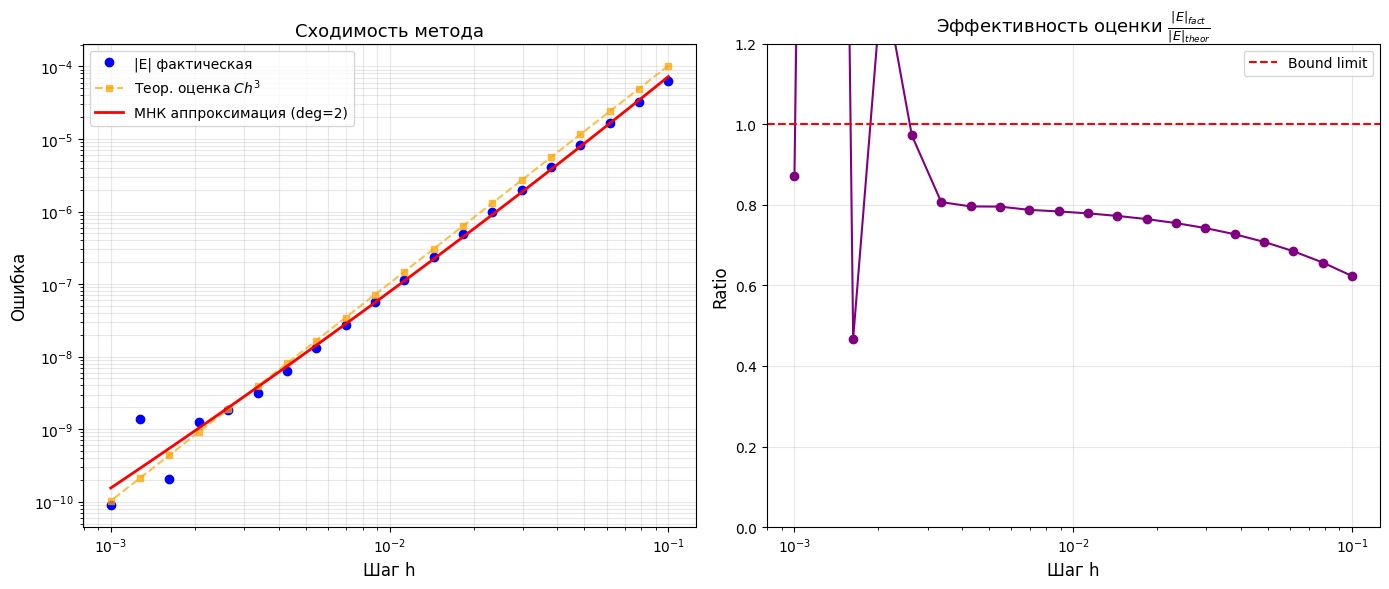

In [7]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4e}'.format)

def D2_5points_forward(f, x0, h):
    """Вторая производная по формуле 5 точек вперёд"""
    return (35/12*f(x0) - 26/3*f(x0+h) + 19/2*f(x0+2*h) 
            - 14/3*f(x0+3*h) + 11/12*f(x0+4*h)) / h**2

# Символьные вычисления
x_sym = sp.Symbol('x')
f_sym = sp.log(x_sym + 1)
d2f_sym = sp.diff(f_sym, x_sym, 2)
d5f_sym = sp.diff(f_sym, x_sym, 5)
d6f_sym = sp.diff(f_sym, x_sym, 6)

# Создаем функции для numpy
f_analitycs = sp.lambdify(x_sym, f_sym, 'numpy')
d2f_analitycs = sp.lambdify(x_sym, d2f_sym, 'numpy')
d5f_analitycs = sp.lambdify(x_sym, d5f_sym, 'numpy')
d6f_analitycs = sp.lambdify(x_sym, d6f_sym, 'numpy')

# Параметры
x0 = 2.0
a, b = 1, 10
h_values = np.logspace(start=-1, stop=-3, num=20, base=10)

# Список для сбора данных
data_list = []
h_max = np.max(h_values)

for h in h_values:
    if x0 + 4*h > b:
        continue

    d2f_approx = D2_5points_forward(f_analitycs, x0, h)
    d2f_true = d2f_analitycs(x0)
    error = np.abs(d2f_approx - d2f_true)

    # Оценка константы
    x_test = np.linspace(x0, x0 + 4*h, 100)
    f5_abs_max = np.max(np.abs(d5f_analitycs(x_test)))
    f6_abs_max = np.max(np.abs(d6f_analitycs(x_test)))
    M = max(f5_abs_max, f6_abs_max) 
    C = M * (h_max/15 + 37/60)
    bound = C * h**3
    
    ratio = error / bound if bound != 0 else 0

    data_list.append({
        'h': h,
        'Actual Error (|E|)': error,
        'Theoretical Bound': bound,
        'Ratio (|E|/Bound)': ratio
    })

df = pd.DataFrame(data_list)
h_vals = df['h'].values
errors = df['Actual Error (|E|)'].values
bounds = df['Theoretical Bound'].values
ratios = df['Ratio (|E|/Bound)'].values

print("=== Результаты анализа ошибки ===")
print(df)
print("\n")


log_h = np.log10(h_vals)
log_err = np.log10(errors)

# 2 - увидеть кривизну, а вообще в идеале 1
poly_degree = 2 

# Формируем матрицу Вандермонда вручную: [1, x, x^2, x^3...]
# column_stack соединяет массивы как столбцы, вот такие пироги!
X_columns = [np.ones_like(log_h)]
for i in range(1, poly_degree + 1):
    X_columns.append(log_h**i)

X = np.column_stack(X_columns)

# Решаем нормальное уравнение: (X^T * X) * A = X^T * Y
alpha = np.linalg.solve(X.T @ X, X.T @ log_err)

print(f"Коэффициенты полинома аппроксимации (степень {poly_degree}):")
for i, coef in enumerate(alpha):
    print(f"a{i} (при log(h)^{i}): {coef:.4f}")

print(f"\nОсновной наклон (a1): {alpha[1]:.4f} (это и есть ваш экспериментальный порядок p)")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1
ax1.loglog(h_vals, errors, 'o', label='|E| фактическая', markersize=6, color='blue')
ax1.loglog(h_vals, bounds, 's--', label='Теор. оценка $Ch^3$', markersize=4, color='orange', alpha=0.7)

# Рисуем аппроксимацию МНК
# Создаем плотную сетку для гладкой линии
log_h_dense = np.linspace(min(log_h), max(log_h), 100)
log_err_fit = np.zeros_like(log_h_dense)
for i, coef in enumerate(alpha):
    log_err_fit += coef * (log_h_dense**i)
err_fit = 10**log_err_fit  # перейти из лог. пространства
h_dense = 10**log_h_dense  # перейти из лог. пространства

ax1.loglog(h_dense, err_fit, 'r-', label=f'МНК аппроксимация (deg={poly_degree})', linewidth=2)

ax1.set_xlabel('Шаг h', fontsize=12)
ax1.set_ylabel('Ошибка', fontsize=12)
ax1.set_title(f'Сходимость метода', fontsize=13)
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

# График 2
ax2.semilogx(h_vals, ratios, 'o-', color='purple', markersize=6)
ax2.axhline(1, color='red', linestyle='--', label='Bound limit')
ax2.set_xlabel('Шаг h', fontsize=12)
ax2.set_ylabel('Ratio', fontsize=12)
ax2.set_title(r'Эффективность оценки $\frac{|E|_{fact}}{|E|_{theor}}$', fontsize=13)
ax2.set_ylim(0, 1.2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
